
=== FOLD 1/5 ===


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth
100%|██████████| 109M/109M [00:00<00:00, 153MB/s]  


Best Val F1: 0.4323

=== FOLD 2/5 ===


Best Val F1: 0.4315

=== FOLD 3/5 ===


Best Val F1: 0.3776

=== FOLD 4/5 ===


Best Val F1: 0.3919

=== FOLD 5/5 ===


Best Val F1: 0.3347


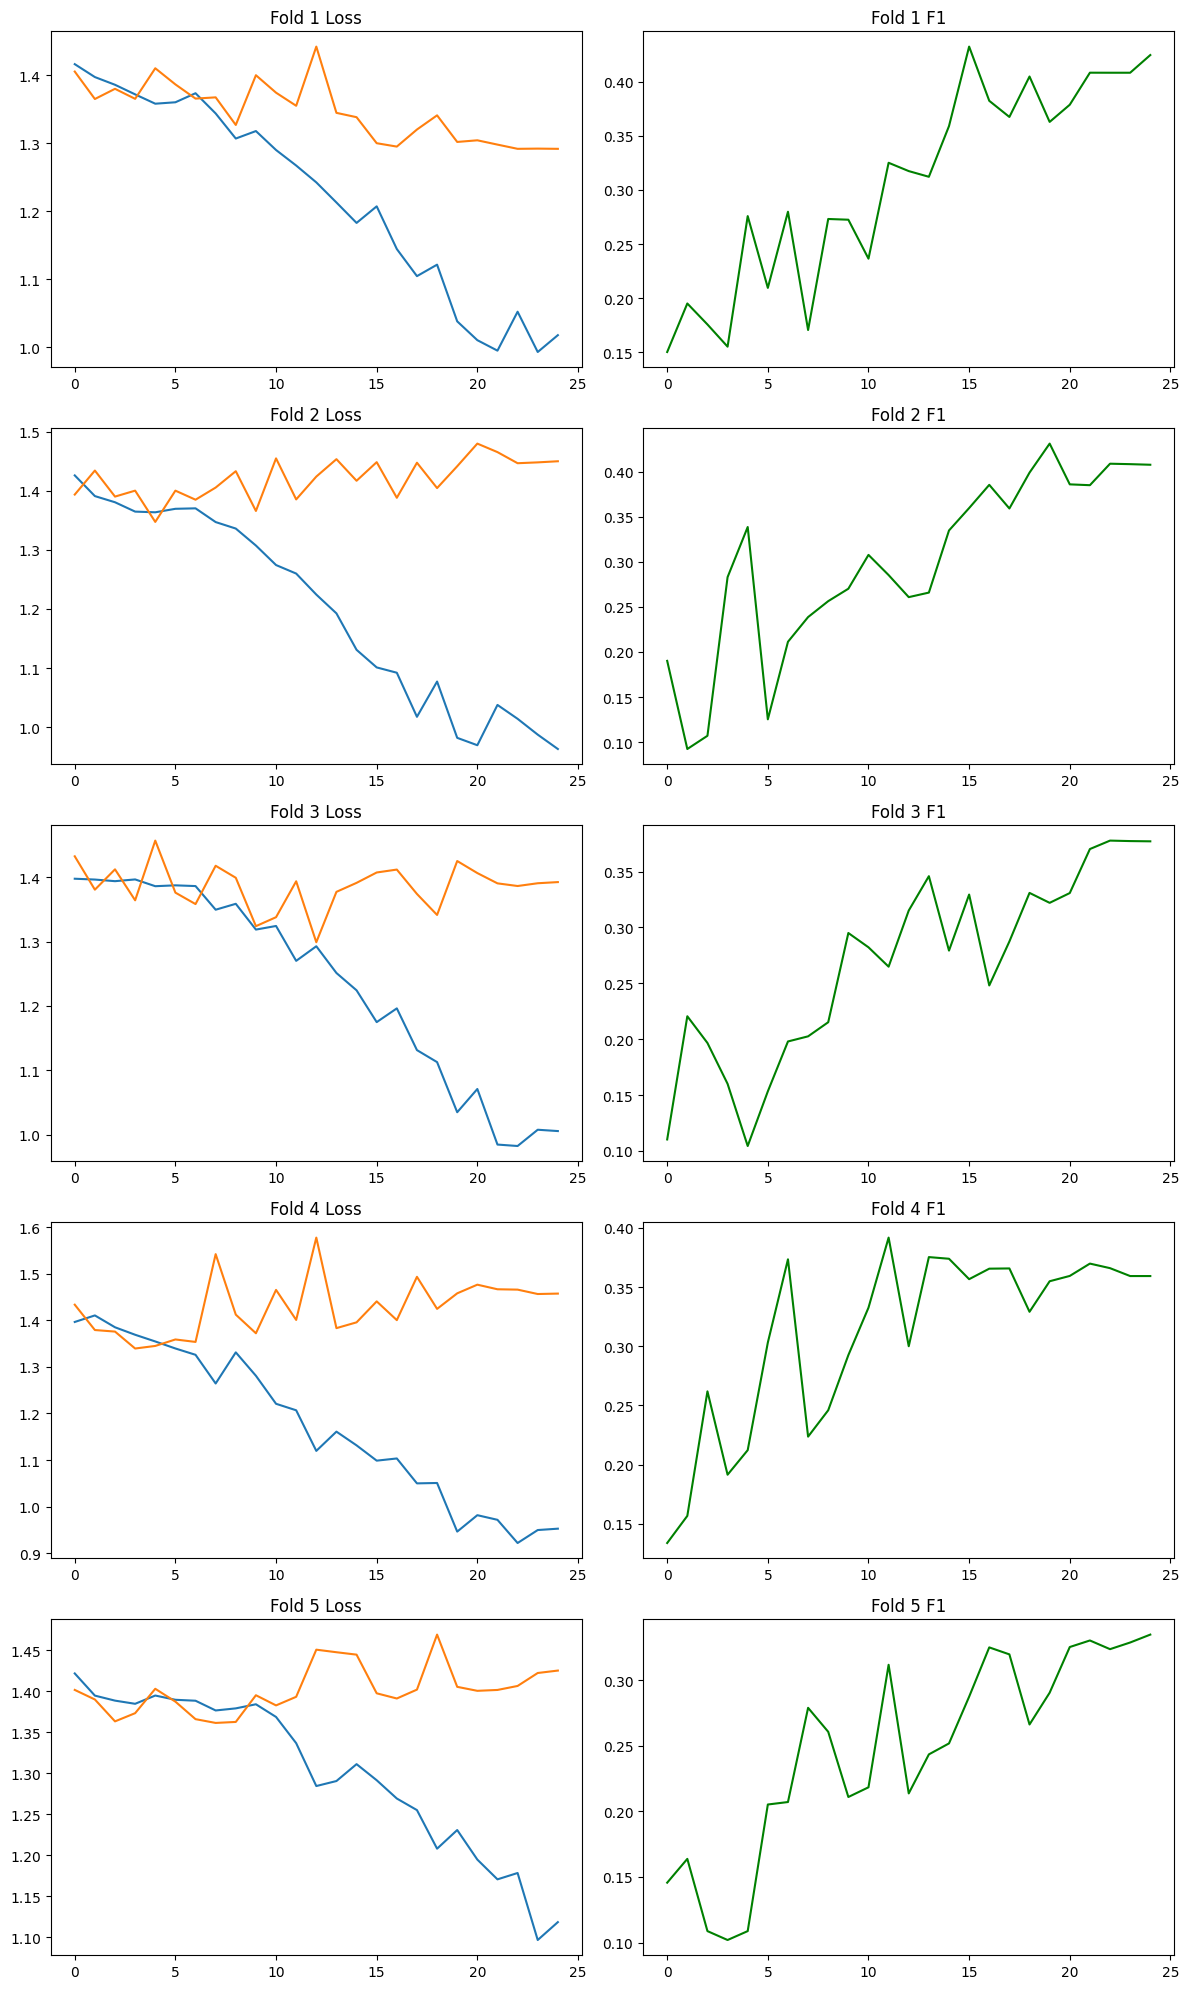

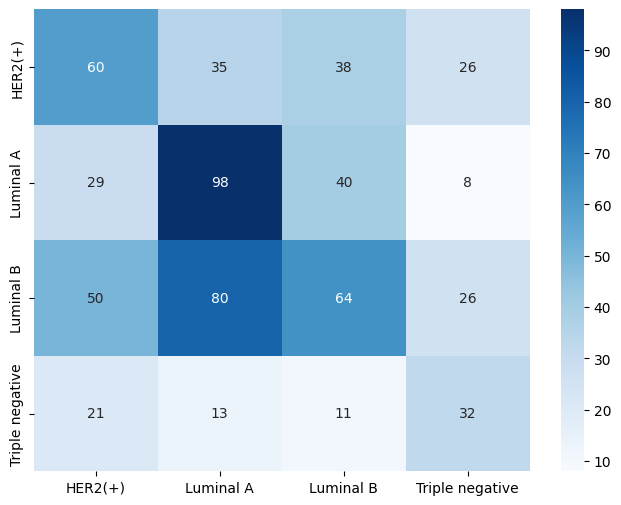


Generazione Submission...


100%|██████████| 60/60 [02:08<00:00,  2.14s/it]

Finito.


In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURAZIONE ---
def find_paths():
    start_dir = "/kaggle/input"
    base_path = None
    for root, dirs, files in os.walk(start_dir):
        if "train_labels.csv" in files:
            base_path = root
            break
    if base_path is None: base_path = "/kaggle/input/dataset" 

    paths = {
        'labels': os.path.join(base_path, "train_labels.csv"),
        'train_img': os.path.join(base_path, "train_data/images"),
        'train_mask': os.path.join(base_path, "train_data/masks"),
        'test_img': os.path.join(base_path, "test_data/images"),
        'test_mask': os.path.join(base_path, "test_data/masks")
    }
    if not os.path.exists(paths['test_img']):
        for root, dirs, files in os.walk(start_dir):
            if root.endswith("test_data/images") or (os.path.basename(root) == "images" and "test_data" in os.path.dirname(root)):
                if any(f.endswith('.png') for f in files):
                    paths['test_img'] = root
                    paths['test_mask'] = root.replace("images", "masks")
                    break
    return paths

PATHS = find_paths()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESIZE_BASE = 320
CROP_SIZE = 256
BATCH_SIZE = 32
VAL_BATCH_SIZE = 8 # Ridotto per TenCrop (10x memoria)
N_FOLDS = 5 # Aumentato a 5 per maggiore stabilità
EPOCHS = 25 # Aumentato leggermente
LR = 2e-4   # ConvNeXt gradisce LR un po' più alto di EfficientNet

# --- 2. DATASET ---
def get_bbox_from_mask(mask):
    if np.sum(mask) == 0: return None
    rows, cols = np.where(mask > 0)
    return np.min(rows), np.max(rows), np.min(cols), np.max(cols)

class TissueDataset(Dataset):
    def __init__(self, dataframe, img_dir, mask_dir, transform=None, is_test=False):
        self.df = dataframe
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['sample_index'] if not self.is_test else row['filename']
        mask_name = img_name.replace("img", "mask")
        
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)
        
        try:
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        except Exception:
            image = np.zeros((RESIZE_BASE, RESIZE_BASE, 3), dtype=np.uint8)
            mask = None

        if mask is not None:
            bbox = get_bbox_from_mask(mask)
            if bbox:
                y_min, y_max, x_min, x_max = bbox
                image = image[y_min:y_max+1, x_min:x_max+1]
        
        image = Image.fromarray(image)
        if self.transform: image = self.transform(image)
        
        if self.is_test: return image, img_name
        else: return image, torch.tensor(row['label_encoded'], dtype=torch.long)

# --- TRANSFORMS (TenCrop) ---
def get_transforms():
    train_trans = transforms.Compose([
        transforms.Resize((RESIZE_BASE, RESIZE_BASE)),
        transforms.RandomCrop(CROP_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # TenCrop: 4 angoli + centro + flips
    val_trans = transforms.Compose([
        transforms.Resize((RESIZE_BASE, RESIZE_BASE)),
        transforms.TenCrop(CROP_SIZE),
        transforms.Lambda(lambda crops: torch.stack([transforms.ToTensor()(crop) for crop in crops])),
        transforms.Lambda(lambda crops: torch.stack([transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(crop) for crop in crops]))
    ])
    return train_trans, val_trans

# --- CUTMIX UTILS ---
def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = np.int64(W * cut_rat)
    cut_h = np.int64(H * cut_rat)
    
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    
    return bbx1, bby1, bbx2, bby2

# --- MODEL (ConvNeXt Tiny) ---
def get_model(num_classes):
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    # ConvNeXt classifier head is model.classifier[2]
    model.classifier[2] = nn.Sequential(
        nn.Dropout(0.3), # Increased dropout
        nn.Linear(model.classifier[2].in_features, num_classes)
    )
    return model.to(DEVICE)

# --- TRAINING LOOP ---
def train_fold(fold, train_idx, val_idx, df, le):
    print(f"\n=== FOLD {fold+1}/{N_FOLDS} ===")
    
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    
    class_counts = train_df['label_encoded'].value_counts().sort_index().values
    class_weights = 1. / class_counts
    sample_weights = [class_weights[l] for l in train_df['label_encoded']]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    
    train_trans, val_trans = get_transforms()
    train_loader = DataLoader(TissueDataset(train_df, PATHS['train_img'], PATHS['train_mask'], train_trans), 
                              batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    val_loader = DataLoader(TissueDataset(val_df, PATHS['train_img'], PATHS['train_mask'], val_trans), 
                            batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=2)
    
    model = get_model(len(le.classes_))
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-2) # Higher weight decay for ConvNeXt
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    history = {'t_loss': [], 'v_loss': [], 'v_f1': []}
    best_f1 = 0.0
    best_preds = []
    best_targets = []
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss_accum = 0.0
        
        for imgs, lbls in tqdm(train_loader, desc=f"Ep {epoch+1}", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            
            # --- CUTMIX ---
            if np.random.rand() < 0.5: # 50% chance
                lam = np.random.beta(1.0, 1.0)
                rand_index = torch.randperm(imgs.size(0)).to(DEVICE)
                target_a = lbls
                target_b = lbls[rand_index]
                bbx1, bby1, bbx2, bby2 = rand_bbox(imgs.size(), lam)
                imgs[:, :, bbx1:bbx2, bby1:bby2] = imgs[rand_index, :, bbx1:bbx2, bby1:bby2]
                lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (imgs.size(-1) * imgs.size(-2)))
                
                out = model(imgs)
                loss = criterion(out, target_a) * lam + criterion(out, target_b) * (1. - lam)
            else:
                out = model(imgs)
                loss = criterion(out, lbls)
                
            loss.backward()
            optimizer.step()
            t_loss_accum += loss.item()
        
        scheduler.step()
        
        # Validation (TenCrop)
        model.eval()
        v_loss_accum = 0.0
        preds, targets = [], []
        
        with torch.no_grad():
            for imgs, lbls in val_loader:
                bs, ncrops, c, h, w = imgs.size()
                imgs = imgs.view(-1, c, h, w).to(DEVICE)
                lbls = lbls.to(DEVICE)
                
                out = model(imgs)
                out = out.view(bs, ncrops, -1).mean(1) # Mean over crops
                
                loss = criterion(out, lbls)
                v_loss_accum += loss.item()
                preds.extend(out.argmax(1).cpu().numpy())
                targets.extend(lbls.cpu().numpy())
        
        t_loss = t_loss_accum / len(train_loader)
        v_loss = v_loss_accum / len(val_loader)
        v_f1 = f1_score(targets, preds, average='macro')
        
        history['t_loss'].append(t_loss)
        history['v_loss'].append(v_loss)
        history['v_f1'].append(v_f1)
        
        if v_f1 > best_f1:
            best_f1 = v_f1
            best_preds = preds
            best_targets = targets
            torch.save(model.state_dict(), f"model_fold_{fold}.pth")
            
    print(f"Best Val F1: {best_f1:.4f}")
    return history, best_targets, best_preds

# --- EXECUTION ---
def run_full_pipeline():
    df = pd.read_csv(PATHS['labels'])
    valid_mask = df['sample_index'].apply(lambda x: os.path.exists(os.path.join(PATHS['train_img'], x)))
    df = df[valid_mask].reset_index(drop=True)
    
    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['label'])
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    all_histories, global_targets, global_preds = [], [], []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label_encoded'])):
        hist, tgt, pred = train_fold(fold, train_idx, val_idx, df, le)
        all_histories.append(hist)
        global_targets.extend(tgt)
        global_preds.extend(pred)
        
    # Plots
    fig, axes = plt.subplots(N_FOLDS, 2, figsize=(12, 4*N_FOLDS))
    if N_FOLDS == 1: axes = [axes]
    for i, h in enumerate(all_histories):
        axes[i][0].plot(h['t_loss'], label='Train')
        axes[i][0].plot(h['v_loss'], label='Val')
        axes[i][0].set_title(f'Fold {i+1} Loss')
        axes[i][1].plot(h['v_f1'], label='Val F1', color='green')
        axes[i][1].set_title(f'Fold {i+1} F1')
    plt.tight_layout()
    plt.show()
    
    cm = confusion_matrix(global_targets, global_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.show()
    return le

# --- SUBMISSION ---
def generate_submission(le):
    print("\nGenerazione Submission...")
    test_files = [f for f in os.listdir(PATHS['test_img']) if f.endswith('.png')]
    test_df = pd.DataFrame({'filename': test_files})
    
    _, val_trans = get_transforms()
    test_ds = TissueDataset(test_df, PATHS['test_img'], PATHS['test_mask'], val_trans, is_test=True)
    test_loader = DataLoader(test_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=2)
    
    models_list = []
    for i in range(N_FOLDS):
        m = get_model(len(le.classes_))
        m.load_state_dict(torch.load(f"model_fold_{i}.pth"))
        m.eval()
        models_list.append(m)
        
    preds, fnames = [], []
    with torch.no_grad():
        for imgs, names in tqdm(test_loader):
            bs, ncrops, c, h, w = imgs.size()
            imgs = imgs.view(-1, c, h, w).to(DEVICE)
            
            avg_probs = torch.zeros((bs, len(le.classes_))).to(DEVICE)
            for model in models_list:
                out = model(imgs)
                out = torch.softmax(out, dim=1)
                out = out.view(bs, ncrops, -1).mean(1)
                avg_probs += out
            
            avg_probs /= N_FOLDS
            preds.extend(le.inverse_transform(avg_probs.argmax(1).cpu().numpy()))
            fnames.extend(names)
            
    pd.DataFrame({'sample_index': fnames, 'label': preds}).to_csv('submission.csv', index=False)
    print("Finito.")

if __name__ == "__main__":
    le = run_full_pipeline()
    generate_submission(le)